# 05 - Evaluación e Interpretabilidad del Modelo

Análisis del modelo Random Forest ya entrenado:
1. Carga de artefactos (modelo, scaler, label_encoder)
2. Importancia de features
3. Matriz de confusión
4. Classification report
5. Visualización de las 2 features más importantes por clase

In [1]:
import sys
sys.path.insert(0, '..')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from src.predict import FEATURE_COLS, load_artifacts

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
FIGURES_DIR = '../reports/figures'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Carga del modelo, scaler y label_encoder

In [2]:
model, scaler, le = load_artifacts()

print(f'Modelo: {type(model).__name__}')
print(f'Clases: {list(le.classes_)}')
print(f'Núm. features: {len(FEATURE_COLS)}')

Modelo: RandomForestClassifier
Clases: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Núm. features: 16


In [3]:
df = pd.read_csv('../data/processed/dry_bean_clean.csv')

X = df[FEATURE_COLS]
y_raw = df['Class']
y = le.transform(y_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')

Train: 10834 muestras | Test: 2709 muestras


## 2. Importancia de Features

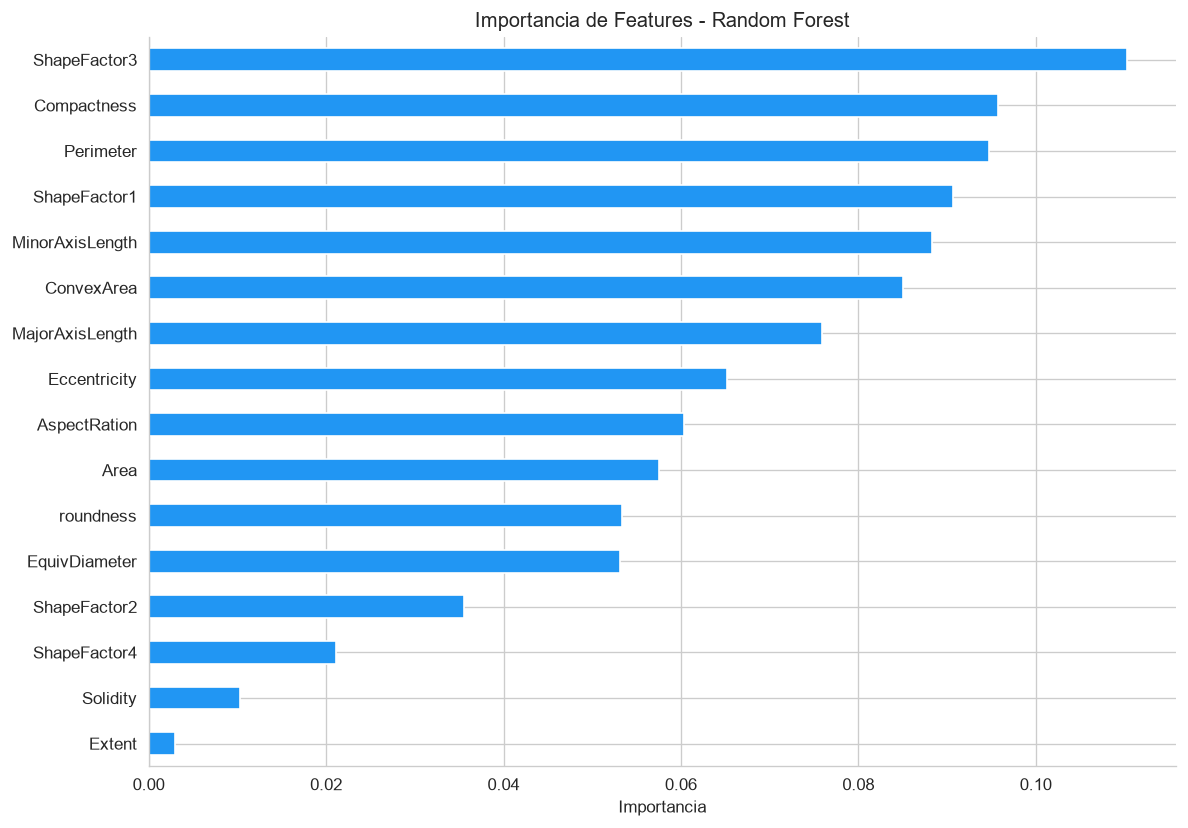


Top 2 features: ['ShapeFactor3', 'Compactness']


In [4]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot.barh(ax=ax, color='#2196F3', edgecolor='white')
ax.set_xlabel('Importancia')
ax.set_title('Importancia de Features - Random Forest')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/feature_importance.png', bbox_inches='tight')
plt.show()

top2 = feat_imp.sort_values(ascending=False).head(2)
print(f'\nTop 2 features: {list(top2.index)}')

## 3. Matriz de Confusión

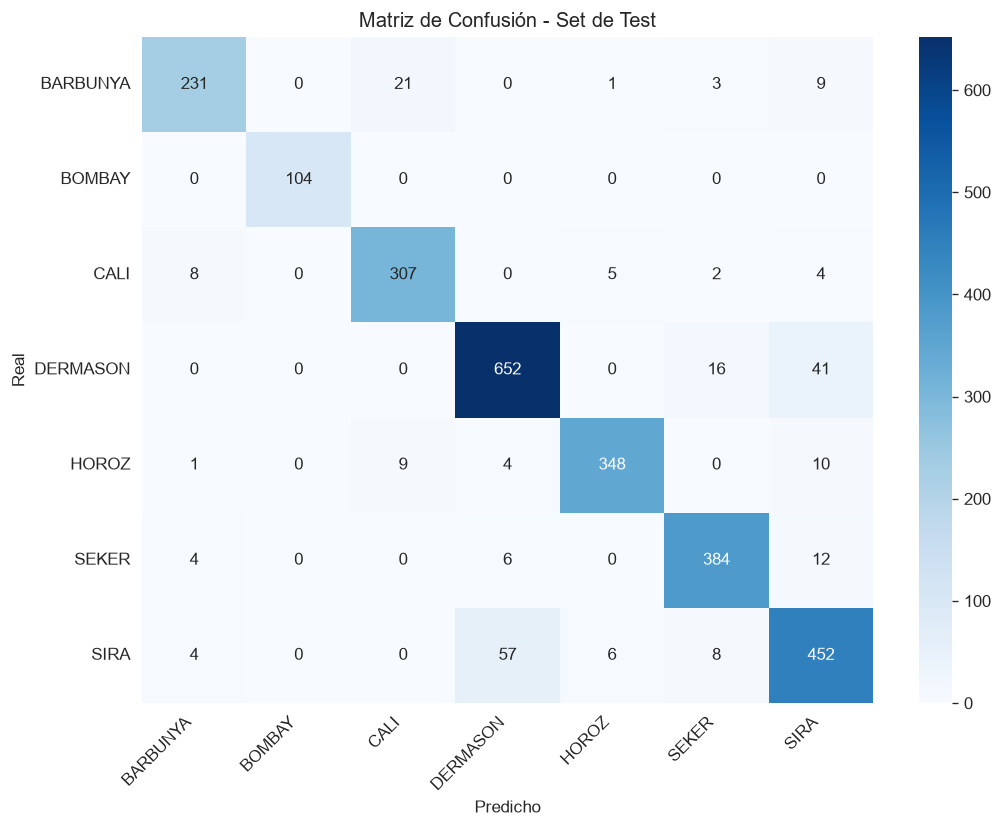

In [5]:
y_pred = model.predict(X_test_scaled)
class_names = list(le.classes_)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión - Set de Test')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/confusion_matrix.png', bbox_inches='tight')
plt.show()

## 4. Classification Report

In [6]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.87      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.91      0.92      0.91       709
       HOROZ       0.97      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.86      0.86       527

    accuracy                           0.91      2709
   macro avg       0.93      0.92      0.93      2709
weighted avg       0.92      0.91      0.91      2709



## 5. Visualización de las 2 Features Más Importantes por Clase

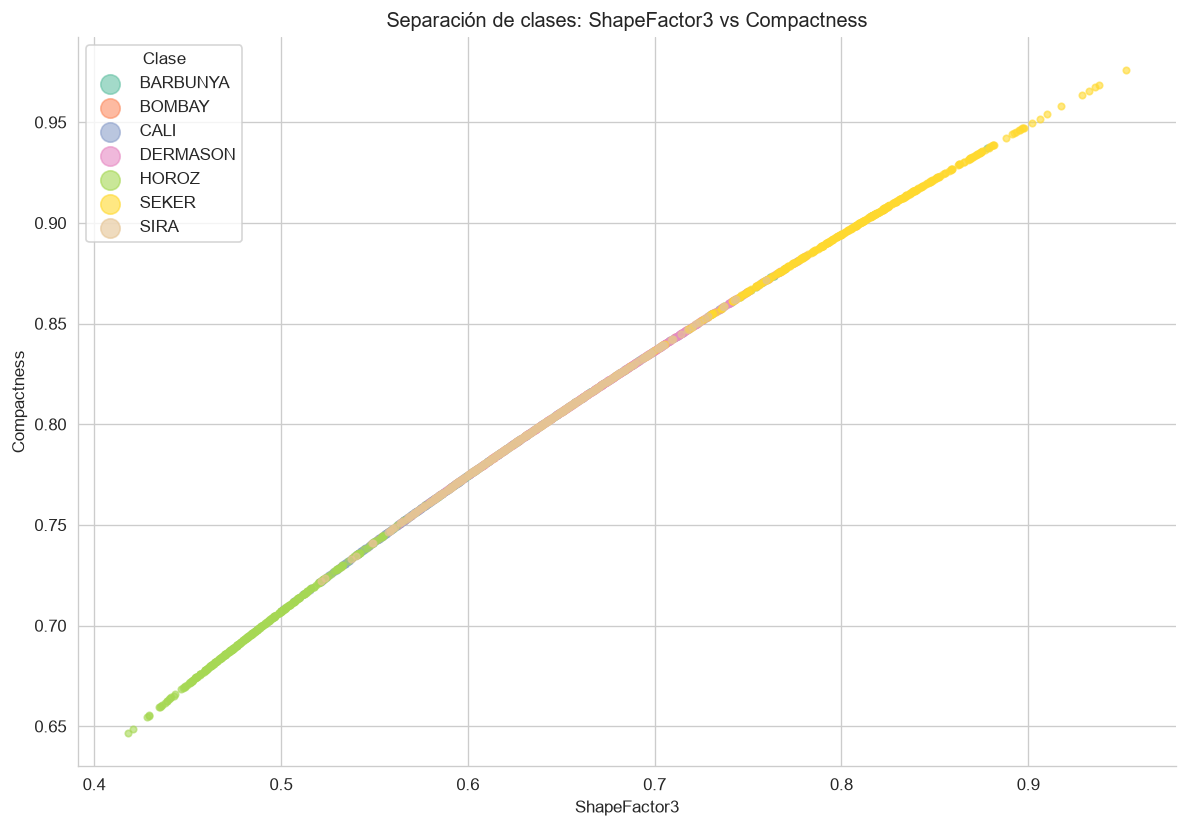

In [7]:
top2_features = list(top2.index)

df_test = X_test.copy()
df_test['Class'] = le.inverse_transform(y_test)

palette = sns.color_palette('Set2', n_colors=len(class_names))

fig, ax = plt.subplots(figsize=(10, 7))
for i, cls in enumerate(class_names):
    mask = df_test['Class'] == cls
    ax.scatter(df_test.loc[mask, top2_features[0]],
               df_test.loc[mask, top2_features[1]],
               label=cls, alpha=0.6, s=15, color=palette[i])

ax.set_xlabel(top2_features[0])
ax.set_ylabel(top2_features[1])
ax.set_title(f'Separación de clases: {top2_features[0]} vs {top2_features[1]}')
ax.legend(title='Clase', markerscale=3, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/top2_features_scatter.png', bbox_inches='tight')
plt.show()